# Homework: Neural Network
$
\newcommand{\xv}{\mathbf{x}}
\newcommand{\wv}{\mathbf{w}}
\newcommand{\yv}{\mathbf{y}}
\newcommand{\tv}{\mathbf{t}}
\newcommand{\zv}{\mathbf{z}}
\newcommand{\uv}{\mathbf{u}}
\newcommand{\vv}{\mathbf{v}}
\newcommand{\bv}{\mathbf{b}}
\newcommand{\av}{\mathbf{a}}
\newcommand{\Chi}{\mathcal{X}}
\newcommand{\R}{\rm I\!R}
\newcommand{\sign}{\text{sign}}
\newcommand{\Ym}{\mathbf{Y}}
\newcommand{\Tm}{\mathbf{T}}
\newcommand{\Xm}{\mathbf{X}}
\newcommand{\Wm}{\mathbf{W}}
\newcommand{\Zm}{\mathbf{Z}}
\newcommand{\Um}{\mathbf{U}}
\newcommand{\Vm}{\mathbf{V}}
\newcommand{\Am}{\mathbf{A}}
\newcommand{\muv}{\boldsymbol\mu}
\newcommand{\Sigmav}{\boldsymbol\Sigma}
\newcommand{\Lambdav}{\boldsymbol\Lambda}
$

## Name: <span style="color:blue"> *Tyler Hudson* </span>

## Utils

In [2]:
from typing import List, Dict, Tuple, Callable
import os
import gc
import traceback
import warnings
from pdb import set_trace

import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
class TodoCheckFailed(Exception):
    pass

def todo_check(asserts, mute=False, success_msg="", **kwargs):
    locals().update(kwargs)
    failed_err = "You passed {}/{} and FAILED the following code checks:\n{}"
    failed = ""
    n_failed = 0
    for check, (condi, err) in enumerate(asserts):
        exc_failed = False
        if isinstance(condi, str):
            try:
                passed = eval(condi)
            except Exception:
                exc_failed = True
                n_failed += 1
                failed += f"\nCheck [{check+1}]: Failed to execute check [{check+1}] due to the following error...\n{traceback.format_exc()}"
        elif isinstance(condi, bool):
            passed = condi
        else:
            raise ValueError("asserts must be a list of strings or bools")

        if not exc_failed and not passed:
            n_failed += 1
            failed += f"\nCheck [{check+1}]: Failed\n\tTip: {err}\n"

    if len(failed) != 0:
        passed = len(asserts) - n_failed
        err = failed_err.format(passed, len(asserts), failed)
        raise TodoCheckFailed(err.format(failed))
    if not mute: print(f"Your code PASSED all the code checks! {success_msg}")

In [6]:
from sklearn.datasets import make_regression

def nonlinear_data(m=100, n=3, seed=0):
    """ Toy data for testing """
    X, _ = make_regression(
        n_samples=m, 
        n_features=n, 
        n_informative=1,
        noise=3.5,
        random_state=seed,
    )
    rng = np.random.RandomState(seed)
    X[:, 0] = np.sort(6 * rng.rand(m, 1) - 3, axis=0).reshape(m,)
    y = (2 + .5* X[:, 0]**2 + X[:, 0]) + rng.rand(m)

    return X, y.reshape(-1, 1)

## Instructions
In this assignment, you will be implementing a simple neural network for non-linear regression. To test the implementation, you will work with the non-linear Concrete Compressive Strength dataset again.

Your job is to read through the assignment and fill in any code segments that are marked by `TODO` headers and comments. Some TODOs will have a `todo_check()` function which will give you a rough estimate of whether your code is functioning as excepted. Other's might not have these checks, like visualization TODOs. Regardless,  all the correct outputs are given below each code cell. It might be useful to copy the contents of certain TODO cells into a new cell so you can try to match the desired output with the output produced by your own code! For visualization TODOs, you simply have to have a plot that looks similar. You can change aspects such as color, titles, or x/y-axis labels if you so wish.

At any point, if you feel lost concerning how to program a specific TODO, take some time and visit the official documentation for each library and read about the methods/functions that you need to use.

## Submission

1. Save the notebook.
2. Enter your name in the appropriate markdown cell provided at the top of the notebook.
3. Select `Kernel` -> `Restart Kernel and Run All Cells`. This will restart the kernel and run all cells. Make sure everything runs without errors and double-check the outputs are as you desire!
4. Submit the `.ipynb` notebook on Canvas.


# Neural Network

## Concrete Compressive Strength Dataset
<center><img src="https://www.constructionplusasia.com/wp-content/uploads/2020/09/Bridge_image-by-Gubin-Yury.jpg" width=600 height=200></center>

In this assignment, we will look at a non-linear dataset called the [Concrete Compressive Strength](https://archive.ics.uci.edu/static/public/165/concrete+compressive+strength.zip) dataset. The goal of this dataset is to predict the strength of a piece of concrete given various different ingredients and age. Below, we have added the description of the dataset and its variables. The target variable is "Concrete compressive strength" or more simply referred to as "Strength."  

> Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and 
ingredients. These ingredients include cement, blast furnace slag, fly ash, water, superplasticizer, coarse aggregate, and fine aggregate.


    Variable Information:
    
    Given is the variable name, variable type, the measurement unit and a brief description. The concrete compressive strength is the regression problem. The order of this listing corresponds to the order of numerals along the rows of the database. 
    
    Name -- Data Type -- Measurement -- Description
    Cement (component 1) -- quantitative -- kg in a m3 mixture -- Input Variable
    Blast Furnace Slag (component 2) -- quantitative -- kg in a m3 mixture -- Input Variable
    Fly Ash (component 3) -- quantitative -- kg in a m3 mixture -- Input Variable
    Water (component 4) -- quantitative -- kg in a m3 mixture -- Input Variable
    Superplasticizer (component 5) -- quantitative -- kg in a m3 mixture -- Input Variable
    Coarse Aggregate (component 6) -- quantitative -- kg in a m3 mixture -- Input Variable
    Fine Aggregate (component 7) -- quantitative -- kg in a m3 mixture -- Input Variable
    Age -- quantitative -- Day (1~365) -- Input Variable
    Strength -- quantitative -- MPa -- Target Variable 

#### TODO 1 (5 points): Data Loading
Complete the TODO by loading the Concrete Compressive Strength. Do so by downloading the "Concrete_Data.csv" file from Canvas, move the file to the same directory as this notebook, and load the file using Pandas. Store the output into the `concrete_df` variable.

**WARNING: Do NOT pass a path specific to your computer! If you do, the TAs will not be able to run your notebook without making changes to it. This is why we are having you move the dataset into the same directory as this notebook.**

In [12]:
# TODO 1
concrete_df = pd.read_csv("Concrete_Data.csv")

In [14]:
todo_check([
    ("os.path.exists('Concrete_Data.csv')", f"The Concrete_Data.csv is not detected in your local path! You need to move the 'Concrete_Data.csv' file to the same location/directory as this notebook which is {os.getcwd()}"),
    ("np.all(concrete_df.iloc[0].values == np.array([ 540.  ,    0.  ,    0.  ,  162.  ,    2.5 , 1040.  ,  676.  ,28.  ,   79.99], \
      dtype=object))", 'The 1st row does not match! Make sure you loaded the right dataset!')
])

Your code PASSED all the code checks! 


In [16]:
concrete_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Cement            1030 non-null   float64
 1   BlastFurnaceSlag  1030 non-null   float64
 2   FlyAsh            1030 non-null   float64
 3   Water             1030 non-null   float64
 4   Superplasticizer  1030 non-null   float64
 5   CoarseAggregate   1030 non-null   float64
 6   FineAggregate     1030 non-null   float64
 7   Age               1030 non-null   int64  
 8   Strength          1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [18]:
concrete_df.describe()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


## Visualization


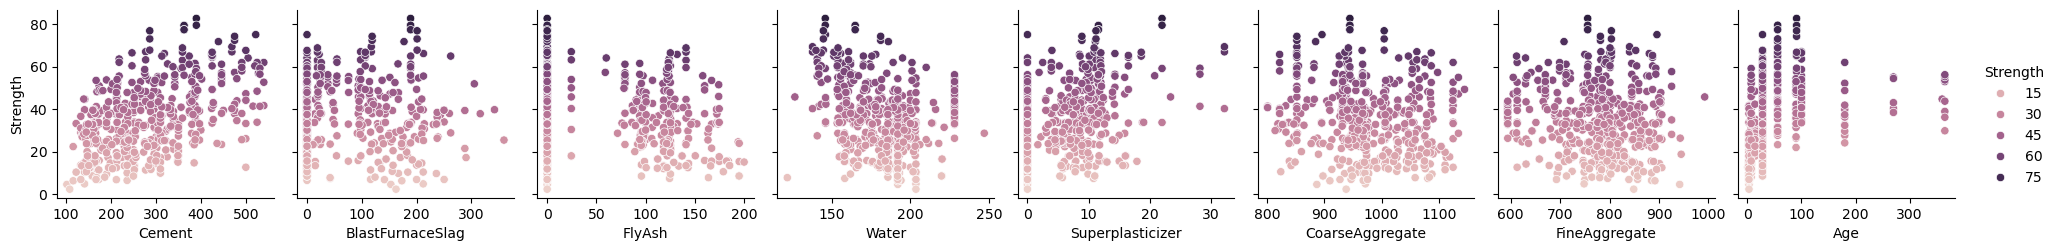

In [20]:
import seaborn as sns
rng = np.random.RandomState(0)
indices = rng.choice(np.arange(len(concrete_df)), size=500, replace=False)
sns.pairplot(
    data=concrete_df.iloc[indices],
    y_vars='Strength',
    x_vars=list(concrete_df.drop('Strength',axis=1).columns),
    hue="Strength",
)
plt.show()

## Data Preprocessing

### Data Splitting

In [22]:
from sklearn.model_selection import train_test_split
def get_train_valid_test_data(
    X: np.ndarray, 
    y: np.ndarray, 
):
    """ Randomizes and then splits the data into train, validation, and test sets.

        Args:
            X: Data given as a 2D matrix

            y: Labels given as a vector 
    """
    X_trn, X_tst, y_trn, y_tst = train_test_split(X, y, train_size=.8, random_state=42)
    X_trn, X_vld, y_trn, y_vld = train_test_split(X_trn, y_trn, train_size=.8, random_state=42)

    return X_trn, y_trn, X_vld, y_vld, X_tst, y_tst

### Putting it all together

#### TODO 2 (10 points): Preprocess Data

Complete the `get_preprocessed_data()` function for performing data preprocessing by satisfying the below requirements. The function should return a tuple of NumPy arrays: `X_trn`, `y_trn`, `X_vld`, `y_vld`, `X_tst`, and `y_tst`. 

1. Separate the data and labels into two separate variables, data `X` and labels `y`. 
2. Split the data and labels into train, validation and test sets.
3. Standardize the training, validation, and testing data.

In [46]:
from sklearn.preprocessing import StandardScaler

def get_preprocessed_data() -> Tuple[np.ndarray, ...]:
    """ Gets preprocessed data for training, validation, and testing.

        Return:
            A tuple of NumPy arrays where indices 0-1 
            contain the training data/targets, indices 2-3
            contain the validation data/targets, and 4-5
            contain the testing data/targets.
    """    
    # TODO 2.1 - 2.3

    X = concrete_df.iloc[:, :-1].to_numpy() 
    y = concrete_df.iloc[:, -1].to_numpy() 

    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_train_valid_test_data(X, y)
    
    # standardize
    scaler = StandardScaler()
    X_trn = scaler.fit_transform(X_trn)
    X_vld = scaler.transform(X_vld)
    X_tst = scaler.transform(X_tst)
    
    return X_trn, y_trn, X_vld, y_vld, X_tst, y_tst

In [48]:
def TEST_get_preprocessed_data():
    X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data()
    
    print(f"X_trn shape: {X_trn.shape}")
    print(f"y_trn shape: {y_trn.shape}")

    print(f"X_vld shape: {X_vld.shape}")
    print(f"y_vld shape: {y_vld.shape}")
    
    print(f"X_tst shape: {X_tst.shape}")
    print(f"y_tst shape: {y_tst.shape}")
    
    print(f"X_trn means:\n{X_trn.mean(axis=0)}")
    print(f"X_vld means:\n{X_vld.mean(axis=0)}")
    print(f"X_tst means:\n{X_tst.mean(axis=0)}")

    todo_check([
        # Split tests
        ("isinstance(X_trn, np.ndarray)", "X_trn must be a NumPy array."),
        ("isinstance(X_vld, np.ndarray)", "X_vld must be a NumPy array."),
        ("isinstance(X_tst, np.ndarray)", "X_tst must be a NumPy array."),
        ("isinstance(y_trn, np.ndarray)", "y_trn must be a NumPy array."),
        ("isinstance(y_vld, np.ndarray)", "y_vld must be a NumPy array."),
        ("isinstance(y_tst, np.ndarray)", "y_tst must be a NumPy array."),
        ("len(y_trn) == 659", "Training data has incorrect number of data samples."),
        ("len(y_vld) == 165", "Validation data has incorrect number of data samples."),
        ("len(y_tst) == 206", "Testing data has incorrect number of data samples."),
        ("np.isclose(y_trn[10], 33.3, rtol=0.01)", "y_trn value was not correct, check implementation and random_state."),
        ("np.isclose(y_vld[11], 53.96, rtol=0.01)", "y_vld value was not correct, check implementation and random_state."),
        ("np.isclose(y_tst[17], 19.35, rtol=0.01)", "y_tst value was not correct, check implementation and random_state."),
        ("X_trn.shape == (659, 8)", "X_trn does not seem to have the right shape, expected (659, 8)."),
        ("X_vld.shape == (165, 8)", "X_vld does not seem to have the right shape, expected (165, 8)."),
        ("X_tst.shape == (206, 8)", "X_tst does not seem to have the right shape, expected (206, 8)."),
        ("np.isclose(X_trn[5,[2, 4, -1]], np.array([-0.84375, -1.05638, -0.71157 ]), rtol=0.01).all()", "X_trn does not seem to have the right number of features, expected 17."),
        # Standardization Tests
        ('np.isclose(X_trn.mean(axis=0).sum(), 0, rtol=0.01)', 'X_trn has potentially incorrect mean values.'),
        ('np.isclose(X_trn.std(axis=0).sum(), 8, rtol=0.01)', 'X_trn has potentially incorrect std values.'),
        ('np.isclose(X_vld.mean(axis=0).sum(), 0.01193, rtol=0.01)', 'X_vld has potentially incorrect mean values.'),
        ('np.isclose(X_vld.std(axis=0).sum(), 8.35889, rtol=0.01)', 'X_vld has potentially incorrect std values.'),
        ('np.isclose(X_tst.mean(axis=0).sum(), 0.07196, rtol=0.01)', 'X_tst has potentially incorrect mean values.'),
        ('np.isclose(X_tst.std(axis=0).sum(), 7.99858, rtol=0.01)', 'X_tst has potentially incorrect std values.'),
        # No Bias Tests
        ("(X_trn[:, 0] != 1).all()", "`X_trn` should have NO bias term added."),
        ("(X_vld[:, 0] != 1).all()", "`X_tvld` should have NO bias term added."),
        ("(X_tst[:, 0] != 1).all()", "`X_tst` should have NO bias term added."),
    ], **locals())
    
TEST_get_preprocessed_data()

X_trn shape: (659, 8)
y_trn shape: (659,)
X_vld shape: (165, 8)
y_vld shape: (165,)
X_tst shape: (206, 8)
y_tst shape: (206,)
X_trn means:
[ 1.16734518e-15 -3.89167707e-17 -5.09624378e-17  8.83494930e-15
  3.95064187e-16 -5.11140616e-16  7.17483736e-15  9.01319147e-18]
X_vld means:
[ 0.09066629 -0.17163991 -0.03834482 -0.01178644 -0.00461011 -0.06623919
  0.1465081   0.06737635]
X_tst means:
[-0.08529739 -0.06121586  0.07312459 -0.05681355  0.03392579 -0.05311408
  0.1207827   0.1005734 ]
Your code PASSED all the code checks! 


## Metrics

In [50]:
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_squared_error as mse

## Activation Functions

#### TODO 3 (5 points): Linear Activation
Complete the TODO by implementing the linear/identity activation function and derivative. Do so by implementing the `activation()` and `derivative()` static methods for the `Linear` class.

1. Implement the linear/identity activation function by completing the `activation()` static method. The returned output should be the same shape as the input.

2. Implement the linear/identity activation function derivative by completing the `derivative()` static method. The returned output should be the same shape as the input.

In [52]:
class Linear():
    """ The linear or identity actionvation function """
    @staticmethod
    def activation(z: np.ndarray) -> np.ndarray:
        """ Computes the output of the linear activation function """
        # TODO 3.1
        
        return z
    
    @staticmethod
    def derivative(z: np.ndarray) -> np.ndarray:
        """ Computes the derivative for the linear activation function """
        # TODO 3.2
        
        return np.ones_like(z)

Input x shape: (100, 1)
Activation y shape: (100, 1)
Derivative dy shape: (100, 1)
Your code PASSED all the code checks! 


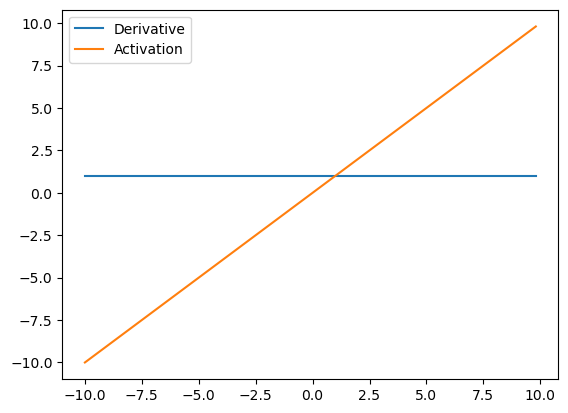

In [54]:
def TEST_Linear():
    x = np.arange(-10, 10 , .2).reshape(-1, 1)
    y = Linear.activation(x)
    dy = Linear.derivative(x)

    print(f"Input x shape: {x.shape}")
    print(f"Activation y shape: {y.shape}")
    print(f"Derivative dy shape: {dy.shape}")

    plt.plot(x ,dy, label='Derivative')
    plt.plot(x ,y, label='Activation')
    plt.legend()
    
    todo_check([
        ("y.shape == x.shape", "The returned output for the `activation()` static method should have the same shape as the input."),
        ("dy.shape == x.shape", "The returned output for the `derivative()` static method should have the same shape as the input."),
        ('(y == x).all()', "`y` values are incorrect."),
        ("(dy == 1).all()", "`yd` derivative values are incorrect.")
    ], **locals())
    
TEST_Linear()

#### TODO 4 (5 points): Tanh Activation

Complete the TODO by implementing the $\tanh$ activation function and derivative. Do so by implementing the `activation()` and `derivative()` static methods for the `Tanh` class.

1. Implement the $\tanh$ activation function by completing the `activation()` static method. The returned output should be the same shape as the input.

2. Implement the $\tanh$ activation function derivative by completing the `derivative()` static method. The returned output should be the same shape as the input.


In [56]:
class Tanh():
    """ The tanh actionvation function """
    @staticmethod
    def activation(z: np.ndarray) -> np.ndarray:
        """ Computes the output of the tanh activation function """
        # TODO 4.1
        
        return np.tanh(z)

    @staticmethod
    def derivative(z: np.ndarray) -> np.ndarray:
        """ Computes the derivative of the tanh activation function """
        # TODO 4.2
        
        tanh_z = np.tanh(z)
        return 1 - tanh_z ** 2

Input x shape: (100, 1)
Activation y shape: (100, 1)
Derivative dy shape: (100, 1)


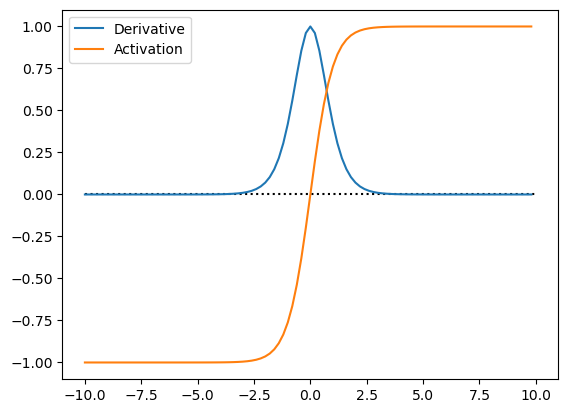

Your code PASSED all the code checks! 


In [58]:
def TEST_Tanh():
    x = np.arange(-10, 10 , .2).reshape(-1, 1)
    y = Tanh.activation(x)
    dy = Tanh.derivative(x)

    print(f"Input x shape: {x.shape}")
    print(f"Activation y shape: {y.shape}")
    print(f"Derivative dy shape: {dy.shape}")

    plt.hlines(0, xmin=-10, xmax=10, colors='black', linestyles='dotted')
    plt.plot(x ,dy, label='Derivative')
    plt.plot(x ,y, label='Activation')
    plt.legend()
    plt.show();

    todo_check([
        ("y.shape == x.shape", "The returned output for the `activation()` static method should have the same shape as the input."),
        ("dy.shape == x.shape", "The returned output for the `derivative()` static method should have the same shape as the input."),
        ('np.all(np.isclose(y.flatten()[50:53], np.array([0.,  0.19737532,  0.37994896])))', "y values are incorrect"),
        ('np.all(np.isclose(dy.flatten()[50:53], np.array([1., 0.96104298, 0.85563879])))', "yd derivative values are incorrect")
    ], **locals())
    
TEST_Tanh()

## Initialize Weights

#### TODO 5 (10 points): Weight Init

Complete the TODO by implementing the weight initialization function `init_weights()`. To do so, you need to initialize the weights `W1` and biasses `b1` for the hidden layer and the weights `W2` and biases `b2` for the output layer. Return the variables `W1`, `b1`, `W2`, and `b2`. 

- The weights should be initialized using samples randomly drawn from a uniform distribution between the values of -0.5 and 0.5 with the shape (inputs, neurons).
- The biases should be initialized to be all ones with the shape (1, neurons).

**Hint**
- NumPy has a random uniform function that should be used (see notes). Using other functions might fail the TODO check. 

In [60]:
def init_weights(
    n_input_features: int, 
    hidden_neurons: int, 
    output_neurons: int, 
) -> Tuple[np.ndarray, ...]:
    """ Initilize the hidden and output layer parameters
        
        Args:
            n_input_features: The number of input features

            hidden_neurons: The number of hidden neurons or units to 
                use in the hidden layer.

            output_neurons: The number of output neurons to use in 
                the output layer.

        Returns:
            A tuple of NumPy arrays containing the weights and biases
            for the hidden and output layers.
    """
    # TODO 5
    W1 = np.random.uniform(-0.5, 0.5, size = (n_input_features, hidden_neurons)) # credit chatGPT for these 2 lines of code
    W2 = np.random.uniform(-0.5, 0.5, size = (hidden_neurons, output_neurons))
    
    b1 = np.ones((1, hidden_neurons))
    b2 = np.ones((1, output_neurons))
    
    return W1, b1, W2, b2

In [62]:
def TEST_init_weights():
    # Init weights and baises
    n, hn, on = 4, 2, 1
    np.random.seed(42)
    W1, b1, W2, b2 = init_weights(
        n_input_features=n,
        hidden_neurons=hn,
        output_neurons=on
    )
    print(f"Hidden layer W1 shape: {W1.shape}")
    print(f"Hidden layer b1 shape: {b1.shape}")
    print(f"Output layer W2 shape: {W2.shape}")
    print(f"Output layer b2 shape: {b2.shape}")

    todo_check([
        ("W1.shape == (n, hn)", f"W1 has the wrong shape, expected {(n, hn)}"),
        ("W2.shape == (hn, on)", f"W2 has the wrong shape, expected {(hn, on)}"),
        ("b1.shape == (1, hn)", f"b1 has the wrong shape, expected {(1, hn)}"),
        ("b2.shape == (1, on)", f"b2 has the wrong shape, expected {(1, on)}"),
        ("np.all(np.isclose(W1.flatten()[:3], np.array([-0.12545988,  0.45071431,  0.23199394]), rtol=.01))", "W1 has incorrect values"),
        ("np.all(b1  == 1)", "b1 has incorrect values"),
        ("np.all(np.isclose(W2.flatten(), np.array([0.10111501, 0.20807258]), rtol=.01))", "W2 has incorrect values"),
        ("np.all(b2 == 1)", "b2 has incorrect values"),
    ], **locals())
    
TEST_init_weights()

Hidden layer W1 shape: (4, 2)
Hidden layer b1 shape: (1, 2)
Output layer W2 shape: (2, 1)
Output layer b2 shape: (1, 1)
Your code PASSED all the code checks! 


## Forward Pass

#### TODO 6 (10 points): Forward
Complete the TODO by implementing the weight initialization function `forward()`. To do so, implement the below equations for the hidden layer and output layer.  Return the variables `Z1`, `A1`, `Z2`, and `A2`.

**Hidden layer equations**

$$
\Zm^{[1]} =  \Xm  \Wm^{[1]} + \bv^{[1]}
$$

$$
\Am^{[1]} = g^{[1]}(\Zm^{[1]} )
$$
where $g^{[1]}$ is the $\tanh$ activation function.

**Output layer equations**

$$
\zv^{[2]} =  \Am^{[1]} \wv^{[2]} + \bv^{[2]}
$$

$$
\av^{[2]} = g^{[2]}(\zv^{[2]})
$$
where $g^{[2]}$ is the linear activation function.

**Hint**
- Reuse the `Tanh` and `Linear` activation classes to compute the activation output. See notes for how to call static methods.

In [64]:
def forward(
    X: np.ndarray, 
    W1: np.ndarray, 
    b1: np.ndarray,
    W2: np.ndarray, 
    b2: np.ndarray, 
) -> Tuple[np.ndarray, ...]:
    """ Forward pass for 2 layer neural network
    
        Args:
            X: Input features
            
            W1: Hidden layer weights 
            
            b1: Hidden layer baises

            W2: Output layer weights 
            
            b2: Output layer baises

        Returns:
            A tuple of NumPy arrays containing the linear combination and 
            acitvation outputs for each layer. These are needed to compute 
            the backward pass.
    """
    Z1, A1, Z2, A2 = None, None, None, None
    # TODO 6

    Z1 = np.dot(X, W1) + b1  # linear combination 
    A1 = Tanh.activation(Z1)  # tanh activation function

    Z2 = np.dot(A1, W2) + b2  # linear combination
    A2 = Linear.activation(Z2)  # linear activation function
    
    return Z1, A1, Z2, A2

In [66]:
def TEST_forward():
    X, y = nonlinear_data()
    np.random.seed(42)
    n, hn, on = X.shape[1], 2, 1
    W1, b1, W2, b2 = init_weights(
        n_input_features=n,
        hidden_neurons=hn,
        output_neurons=on
    )
    Z1, A1, Z2, A2 = forward(X=X, W1=W1, b1=b1, W2=W2, b2=b2)
    mse_score = mse(y, A2)
    print(f'Z1 shape: {Z1.shape}')
    print(f'A1 shape: {A1.shape}')
    print(f'Z2 shape: {Z2.shape}')
    print(f'A2 or y_hat shape: {A2.shape}')
    print(f"MSE after 1 forward pass: {mse_score}")

    todo_check([
        ("Z1.shape == (len(X), hn)", f"Z1 has the wrong shape, expected {(len(X), hn)}"),
        ("A1.shape == (len(X), hn)", f"A1 has the wrong shape, expected {(len(X), hn)}"),
        ("Z2.shape == (len(X), on)", f"Z2 has the wrong shape, expected {(len(X), on)}"),
        ("A2.shape == (len(X), on)", f"A2 or y_hat has the wrong shape, expected {(len(X), on)}"),
        ("np.isclose(mse_score, 12.66850, rtol=.01)",'mse_score is incorrect'),
        ("np.all(np.isclose(Z1.sum(), 183.27444, rtol=.01))", "Z1 has potentially incorrect values"),
        ("np.all(np.isclose(A1.sum(), 119.82372, rtol=.01))", "A1 has potentially incorrect values"),
        ("np.all(np.isclose(Z2.sum(), 88.934361, rtol=.01))", "Z2 has potentially incorrect values"),
        ("np.all(np.isclose(A2.sum(), 88.934361, rtol=.01))", "A2 has potentially incorrect values"),
    ], **locals())
TEST_forward()

Z1 shape: (100, 2)
A1 shape: (100, 2)
Z2 shape: (100, 1)
A2 or y_hat shape: (100, 1)
MSE after 1 forward pass: 12.668507283698458
Your code PASSED all the code checks! 


## Backward Pass

#### TODO 7 (10 points): Output Layer Grads
Complete the TODO by implementing the `output_layer_grads()` function to compute the average gradients for the output layer weights and biases. To do so, implement the below partial derivative chain rule equation for the output layer. Return the variables `W2_avg_grad` and `b2_avg_grad` which contain the average gradient for the weights and biases. 

$$
\begin{align}
\frac{\partial MSE}{\partial \wv^{[2]}} &=  
\color{yellow}\frac{\partial MSE}{\partial \av^{[2]}} 
\color{green}\frac{\partial \av^{[2]}}{\partial \zv^{[2]}} 
\color{purple}\frac{\partial \zv^{[2]}}{\partial \wv^{[2]}}\\
\\
&= \color{purple} \Big ( \frac{\partial \zv^{[2]}}{\partial \wv^{[2]}} \Big ) ^\top  \color{white} \cdot 
\color{white} \Big (
\color{yellow}\frac{\partial MSE}{\partial \av^{[2]}}\color{white} * 
\color{green}\frac{\partial \av^{[2]}}{\partial \zv^{[2]} } 
\color{white} \Big )  \\
\\
&=  
\color{purple} \Am^{[1]\top} \color{white} \cdot \Big( 
\color{yellow} (\av^{[2]} - {\yv}) \color{white} * 
\color{green} \mathbf{1}
\color{white} \Big ) 
\end{align}
$$

$$
\begin{align}
\frac{\partial MSE}{\partial \bv^{[2]}} &=  
\color{yellow}\frac{\partial MSE}{\partial \av^{[2]}} 
\color{green}\frac{\partial \av^{[2]}}{\partial \zv^{[2]} } 
\color{purple}\frac{\partial \zv^{[2]}}{\partial \bv^{[2]}}\\
\\
&= \color{purple} \Big ( \frac{\partial \zv^{[2]}}{\partial \bv^{[2]}} \Big ) ^\top  \color{white} \cdot 
\color{white} \Big (
\color{yellow}\frac{\partial MSE}{\partial \av^{[2]}}\color{white} * 
\color{green}\frac{\partial \av^{[2]}}{\partial \zv^{[2]} } 
\color{white} \Big )  \\
\\
&=  
\color{purple} \mathbf{1}^{\top} \color{white} \cdot \Big( 
\color{yellow} (\av^{[2]} - {\yv}) \color{white} * 
\color{green} \mathbf{1}
\color{white} \Big ) 
\end{align}
$$

**Hint**
- The function `output_layer_grads()` has more arguments than are needed. This means you might not use all the arguments passed to the function!
- Use the `Linear` activation class to compute the linear activation function derivative. See notes for how to call static methods.
- Do not forget, you need to divide by the total number of data samples to get the average gradient!

In [180]:
def output_layer_grads(
    X: np.ndarray,
    y: np.ndarray,
    W1: np.ndarray,
    Z1: np.ndarray,
    A1: np.ndarray,
    W2: np.ndarray,
    Z2: np.ndarray,
    A2: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """ Compute gradients for the output layer parameters
        
        Note:
            You might not use all the passed arguments!
    
        Args:
            X: Input data given as a matrix
            
            y: Ground truth labels given as a column vector

            W1: Hidden layer weights
            
            Z1: Linear combination output for hidden layer

            A1: Activation output for hidden layer
            
            W2: Output layer weights

            Z2: Linear combination output for the output layer

            A2: Activation output or the output layer. Also 
                referred to as y_hat.
            
        Return:
            A tuple of NumPy arrays containing the average gradient 
            for the output layer weights and biases.
    """
    # TODO 7
    W2_avg_grad, b2_avg_grad = None, None

    m = y.shape[0]  # number of samples

    y = y.reshape(-1, 1)
    
    dZ2 = A2 - y  # gradiant
    
    W2_avg_grad = (1 / m) * np.dot(A1.T, dZ2)  # average gradient for weights
    b2_avg_grad = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)  # average gradient for biases
    
    return W2_avg_grad, b2_avg_grad

In [182]:
def TEST_output_layer_grads():
    X, y = nonlinear_data()
    np.random.seed(42)
    n, hn, on = X.shape[1], 2, 1
    W1, b1, W2, b2 = init_weights(
        n_input_features=n,
        hidden_neurons=hn,
        output_neurons=on
    )
    Z1, A1, Z2, A2 = forward(X=X, W1=W1, b1=b1, W2=W2, b2=b2)
    W2_avg_grad, b2_avg_grad = output_layer_grads(X, y, W1, Z1, A1, W2, Z2, A2)
    print(f"W2_avg_grad shape: {W2_avg_grad.shape}")
    print(f"W2_avg_grad:\n{W2_avg_grad}")
    print(f"b2_avg_grad shape: {b2_avg_grad.shape}")
    print(f"b2_avg_grad: {b2_avg_grad}")
    
    todo_check([
        ("W2_avg_grad.shape == (hn, on)", f"W2_avg_grad has the wrong shape, expected {(hn, on)}"),
        ("b2_avg_grad.shape == (1, on)", f"b2_avg_grad has the wrong shape, expected {(1, on)}"),
        ("np.all(np.isclose(W2_avg_grad.flatten(), np.array([-1.9263721, -1.90699268]),rtol=.01))", "W2_avg_grad has incorrect values"),
        ("np.all(np.isclose(b2_avg_grad.flatten(), np.array([-2.98494501]),rtol=.01))", "b1_avg_grad has incorrect values"),
    ], **locals())
TEST_output_layer_grads()

W2_avg_grad shape: (2, 1)
W2_avg_grad:
[[-1.9263721 ]
 [-1.90699268]]
b2_avg_grad shape: (1, 1)
b2_avg_grad: [[-2.98494501]]
Your code PASSED all the code checks! 


### Hidden Layer

#### TODO 8 (10 points): Hidden Layer Grads
Complete the TODO by implementing the `hidden_layer_grads()` function to compute the average gradients for the hidden layer weights and biases. To do so, implement the below partial derivative chain rule equation for the hidden layer. Return the variables `W1_avg_grad` and `b1_avg_grad` which contain the average gradient for the weights and biases. 

$$
\begin{align}
\frac{\partial MSE}{\partial \Wm^{[1]}} &= 
\color{yellow}{\frac{\partial MSE}{\partial \av^{[2]}}} 
\color{green}{\frac{\partial \av^{[2]}}{\partial \zv^{[2]}}} 
\color{blue}{\frac{\partial \zv^{[2]}}{\partial \Am^{[1]}}} 
\color{red}{\frac{\partial \Am^{[1]}}{\partial \Zm^{[1]}}} 
\color{purple}{\frac{\partial \Zm^{[1]}}{\partial \Wm^{[1]}}} \\
\\
 &=
\color{purple}{\frac{\partial \Zm^{[1]}}{\partial \Wm^{[1]}}^\top} \color{white} \cdot 
\Big( \color{yellow}{\frac{\partial MSE}{\partial \av^{[2]}}} \color{white} * 
\color{green}{\frac{\partial \av^{[2]}}{\partial \zv^{[2]}}} \color{white} \cdot 
\color{blue}{\frac{\partial \zv^{[2]}}{\partial \Am^{[1]}}^\top} \color{white} * 
\color{red}{\frac{\partial \Am^{[1]}}{\partial \Zm^{[1]}}} \color{white} \Big ) 
 \\
 \\
&=
\color{purple}\Xm^\top \color{white} \cdot \Big ( 
\color{yellow} ( \av^{[2]} - {\yv} ) \color{white} * 
\color{green} \mathbf{1} \color{white} \cdot 
\color{blue} \Wm^{[2]\top} \color{white} *
\color{red} \big (  1 - \tanh^2(\Zm^{[1]}) \big )%\big ( g(\Zm^{[1]}) * (\mathbf{1}  - g( \Zm^{[1]}) \big ) 
\color{white} \Big ) 
\end{align}
$$

$$
\begin{align}
\frac{\partial MSE}{\partial \bv^{[1]}} &= 
\color{yellow}{\frac{\partial MSE}{\partial \av^{[2]}}} 
\color{green}{\frac{\partial \av^{[2]}}{\partial \zv^{[2]}}} 
\color{blue}{\frac{\partial \zv^{[2]}}{\partial \Am^{[1]}}} 
\color{red}{\frac{\partial \Am^{[1]}}{\partial \Zm^{[1]}}} 
\color{purple}{\frac{\partial \Zm^{[1]}}{\partial \bv^{[1]}}} \\
\\
 &=
\color{purple}{\frac{\partial \Zm^{[1]}}{\partial \bv^{[1]} }^\top} \color{white} \cdot 
\Big( \color{yellow}{\frac{\partial MSE}{\partial \av^{[2]}}} \color{white} * 
\color{green}{\frac{\partial \av^{[2]}}{\partial \zv^{[2]}}} \color{white} \cdot 
\color{blue}{\frac{\partial \zv^{[2]}}{\partial \Am^{[1]}}^\top} \color{white} * 
\color{red}{\frac{\partial \Am^{[1]}}{\partial \Zm^{[1]}}} \color{white} \Big ) 
 \\
 \\
&=
\color{purple}\mathbf{1}^\top \color{white} \cdot \Big ( 
\color{yellow} ( \av^{[2]} - {\yv} ) \color{white} * 
\color{green} \mathbf{1} \color{white} \cdot 
\color{blue} \Wm^{[2]\top} \color{white} *
\color{red} \big ( 1 - \tanh^2(\Zm^{[1]}) \big ) 
\color{white} \Big ) 
\end{align}
$$

**Hint**
- The function `hidden_layer_grads()` has more arguments than are needed. This means you might not use all the arguments passed to the function!
- Use the `Linear` activation class to compute the linear activation function derivative. See notes for how to call static methods.
- Use the `Tanh` activation class to compute the $\tanh$ activation function derivative. See notes for how to call static methods.
- Do not forget, you need to divide by the total number of data samples to get the average gradient!

In [186]:
def hidden_layer_grads(
    X: np.ndarray,
    y: np.ndarray,
    W1: np.ndarray,
    Z1: np.ndarray,
    A1: np.ndarray,
    W2: np.ndarray,
    Z2: np.ndarray,
    A2: np.ndarray
) -> Tuple[np.ndarray, np.ndarray]:
    """ Compute gradients for the hidden layer parameters
        
        Note:
            You might not use all the passed arguments!
    
        Args:
            X: Input data given as a matrix
            
            y: Ground truth labels given as a column vector

            W1: Hidden layer weights
            
            Z1: Linear combination output for hidden layer

            A1: Activation output for hidden layer
            
            W2: Output layer weights

            Z2: Linear combination output for the output layer

            A2: Activation output or the output layer. Also 
                referred to as y_hat.
            
        Return:
            A tuple of NumPy arrays containing the average gradient 
            for the hidden layer weights and biases.
    """
    # TODO 8
    W1_avg_grad, b1_avg_grad = None, None

    m = y.shape[0] 
    y = y.reshape(-1, 1)

    dZ2 = A2 - y  # loss gradient w.r.t. Z2

    # backpropagate to the hidden layer
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * (1 - np.tanh(Z1) ** 2) 

    W1_avg_grad = (1 / m) * np.dot(X.T, dZ1)  
    b1_avg_grad = (1 / m) * np.sum(dZ1, axis = 0, keepdims = True) 
    
    return W1_avg_grad, b1_avg_grad

In [188]:
def TEST_output_layer_grads():
    X, y = nonlinear_data()
    np.random.seed(42)
    n, hn, on = X.shape[1], 2, 1
    W1, b1, W2, b2 = init_weights(
        n_input_features=n,
        hidden_neurons=hn,
        output_neurons=on
    )
    Z1, A1, Z2, A2 = forward(X=X, W1=W1, b1=b1, W2=W2, b2=b2)
    W1_avg_grad, b1_avg_grad = hidden_layer_grads(X, y, W1, Z1, A1, W2, Z2, A2)
    print(f"W1_avg_grad shape: {W1_avg_grad.shape}")
    print(f"W1_avg_grad:\n{W1_avg_grad}")
    print(f"b1_avg_grad shape: {b1_avg_grad.shape}")
    print(f"b1_avg_grad: {b1_avg_grad}")
    todo_check([
        ("W1_avg_grad.shape == (n, hn)", f"W1_avg_grad has the wrong shape, expected {(n, hn)}"),
        ("b1_avg_grad.shape == (1, hn)", f"b1_avg_grad has the wrong shape, expected {(1, hn)}"),
        ("np.all(np.isclose(W1_avg_grad.flatten(), np.array([0.71188803,  0.433636,   -0.15409518,  0.11297837,  0.29699145, -0.09406183]),rtol=.01))", "W1_avg_grad has incorrect values"),
        ("np.all(np.isclose(b1_avg_grad.flatten(), np.array([ 0.69360168, -0.41074079]),rtol=.01))", "b1_avg_grad has incorrect values"),
    ], **locals())
TEST_output_layer_grads()

W1_avg_grad shape: (3, 2)
W1_avg_grad:
[[ 0.71188803  0.433636  ]
 [-0.15409518  0.11297837]
 [ 0.29699145 -0.09406183]]
b1_avg_grad shape: (1, 2)
b1_avg_grad: [[ 0.69360168 -0.41074079]]
Your code PASSED all the code checks! 


## Coding a Neural Network

#### TODO 9 (20 points): Neural Network 
Compete the TODO by finishing the `NeuralNetwork` class implementation.

**`fit()` TODOs**

Follow the below steps to implement the `fit()` method. Feel free to reuse code from prior homework.

1. Implement the `fit()` function according to the pseudocode provided below.
    1. Hint: Subscript $b$ corresponding to index samples at current batch, while $B$ corresponds to the size of the batch (i.e., number of samples in the batch).
    2. Lines 23-27 will be used to compute and store the training/validation RMSE for the current epoch. Learning curves will not plot without this!
   
<center><img src="https://live.staticflickr.com/65535/54138176380_7d314d8064_c.jpg" width="701" height="800" alt="neural network pseudocode"/></center>

**`predict()` TODOs**

Follow the below steps to implement the `predict()` method. Feel free to reuse code from prior homework.

2. Compute the predictions by performing a forward pass using the input data. Return the predictions as a 2D column vector.

**Hint**
- You do not need to reimplement any equations in the code that we have already implemented (e.g., weight initialization, forward pass, backward pass, RMSE, etc.), simply reuse those functions.

In [192]:
def get_batches(
    data_len: int, 
    batch_size: int = 32,
) -> List[np.ndarray]:
    """ Generates mini-batches based on the data indexes
        
        Args:
            data_len: Length of the data or number of data samples 
                in the data. This is used to generate the indices of
                the data.
            
            batch_size: Size of each mini-batch where the last mini-batch
                might be smaller than the rest if the batch_size does not 
                evenly divide the data length.

        Returns:
            A list of NumPy array's holding the indices of batches
    """
    indices = np.arange(data_len)
    np.random.shuffle(indices)
    batches = [indices[i:i+batch_size] for i in range(0, data_len, batch_size)]

    return batches

In [194]:
class NeuralNetwork():
    def __init__(self,
        hidden_neurons: int,
        output_neurons: int,
        alpha: float, 
        batch_size: int,
        epochs: int = 1,
        seed: int = 0,
    ):
        """ A two layer neural network using SGD
            
            Attributes:
                hidden_neurons: Number of hidden units/neurons.
                
                output_neurons: Number of output neuorns
                
                alpha: learning rate or step size.
                
                batch_size: Size of mini-batches for mini-batch gradient
                    descent.
                
                epochs: Number of epochs to run for mini-batch
                    gradient descent.
                    
                seed: Seed to be used for NumPy's RandomState class
                    or universal seed np.random.seed() function.
    
                W1: Hidden layer weights with shape (inputs, neurons)
                
                b1: Hidden layer baises with shape (1, neurons)
                
                W2: Output layer weights with shape (inputs, neurons)
                
                b2: Output layer baises with shape (1, neurons)
    
                trn_error: Stores the training error for each epoch.
    
                vld_error: Stores the validation error for each epoch.
        """
        self.hidden_neurons = hidden_neurons
        self.output_neurons = output_neurons
        self.batch_size = batch_size
        self.alpha = alpha
        self.epochs = epochs
        self.seed = seed
        
        self.W1, self.b1 = None, None
        self.W2, self.b2 = None, None
        self.trn_error = None
        self.vld_error = None

    def fit(
        self,
        X: np.ndarray, 
        y: np.ndarray,
        X_vld: np.ndarray = None, 
        y_vld:np.ndarray = None,
    ): 
        """ Trains a basic two layer neural network using SGD
        
            Args:
                X: Training data given as a 2D matrix

                y: Training labels given as a 2D column vector

                X_vld: Validation data given as a 2D matrix. Used 
                    to compute the validation RMSE for each epoch.

                y_vld: Validation labels given as a 2D matrix. Used 
                    to compute the validation RMSE for each epoch.
                
            Returns:
                The class's own object reference. 
        """
        np.random.seed(self.seed)
        self.trn_error = []
        self.vld_error = []
        
        # TODO 9.1

        self.W1, self.b1, self.W2, self.b2 = init_weights(
            n_input_features=X.shape[1],
            hidden_neurons=self.hidden_neurons,
            output_neurons=self.output_neurons
        )
    
        for epoch in range(self.epochs):
            batches = get_batches(data_len=X.shape[0], batch_size=self.batch_size)
            
            for batch in batches:
                # current batcj
                X_b = X[batch]
                y_b = y[batch]
                
                Z1, A1, Z2, A2 = forward(X_b, self.W1, self.b1, self.W2, self.b2)
                
                # gradients for output layer
                W2_grad, b2_grad = output_layer_grads(X_b, y_b, self.W1, Z1, A1, self.W2, Z2, A2)
                
                # gradients for hidden layer
                W1_grad, b1_grad = hidden_layer_grads(X_b, y_b, self.W1, Z1, A1, self.W2, Z2, A2)
                
                # update weights and biases
                self.W2 -= self.alpha * W2_grad
                self.b2 -= self.alpha * b2_grad
                self.W1 -= self.alpha * W1_grad
                self.b1 -= self.alpha * b1_grad
            
            # rmse
            y_hat_trn = self.predict(X)
            trn_rmse = np.sqrt(mse(y, y_hat_trn))
            self.trn_error.append(trn_rmse)
    
            # Compute validation RMSE, if validation data is provided - This code provided by chatGPT
            if X_vld is not None and y_vld is not None:
                y_hat_vld = self.predict(X_vld)
                vld_rmse = np.sqrt(mse(y_vld, y_hat_vld))
                self.vld_error.append(vld_rmse)
            else:
                # Ensure `self.vld_error` matches `self.trn_error` in length
                self.vld_error.append(None)
    
        return self
        
    def predict(self, X: np.ndarray):
        """ Make predictions using forward pass.

            Args:
                X: Testing data given as a 2D matrix

            Returns:
                A 2D column vector of predictions for each data sample in X
        """
        # TODO 9.2
    
        _, _, _, A2 = forward(X, self.W1, self.b1, self.W2, self.b2) # this syntax is from chatGPT
        return A2

Train MSE: 0.16430898806918098
Validation MSE: 0.2636041130381321


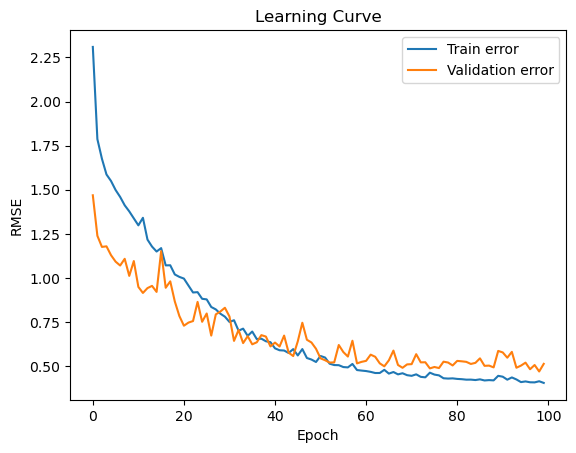

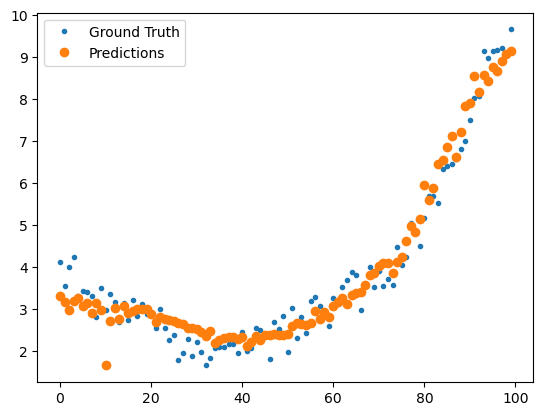

Your code PASSED all the code checks! 


In [196]:
def TEST_NeuralNetwork():
    X, y = nonlinear_data()
    X_trn, X_vld, y_trn, y_vld = train_test_split(X, y, random_state=42)
    nn = NeuralNetwork(
        hidden_neurons=25,
        output_neurons=1,
        batch_size=64,
        alpha=0.05,
        epochs=100,
        seed=0,
    )
    nn.fit(X_trn, y_trn, X_vld=X_vld, y_vld=y_vld)
    y_hat_trn = nn.predict(X_trn)
    trn_mse_score = mse(y_trn, y_hat_trn)
    print(f"Train MSE: {trn_mse_score}")
    
    y_hat_vld = nn.predict(X_vld)
    vld_mse_score = mse(y_vld, y_hat_vld)
    print(f"Validation MSE: {vld_mse_score}")

    plt.plot(nn.trn_error, label='Train error')
    plt.plot(nn.vld_error, label='Validation error')
    plt.title("Learning Curve")
    plt.ylabel("RMSE")
    plt.xlabel("Epoch")
    plt.legend()
    plt.show()

    plt.plot(y, '.', label='Ground Truth')
    plt.plot(nn.predict(X), 'o', label='Predictions')
    plt.legend()
    plt.show()
  
    todo_check([
        ("len(nn.trn_error) == 100", "Expected 100 training evaluations for `self.trn_error`. Make sure the code for tracking error was aded."),
        ("len(nn.vld_error) == 100", "Expected 100 validation evaluations for `self.vld_error`. Make sure the code for tracking error was aded."),
        ("np.isclose(nn.W1.sum(), -0.4564, rtol=0.01)", "Incorrect W1 values."),
        ("np.isclose(nn.b1.sum(), 26.3537, rtol=0.01)", "Incorrect b1 values."),
        ("np.isclose(nn.W2.sum(), 1.2612, rtol=0.01)", "Incorrect W2 values."),
        ("np.isclose(nn.b2.sum(), 1.7042, rtol=0.01)", "Incorrect b2 values."),
        ("np.isclose(vld_mse_score, .26360, rtol=0.01)", "Incorrect validation MSE score."),
    ], **locals())

TEST_NeuralNetwork()

## Concrete Training

#### TODO 10 (15 points): Training and Evaluating
Complete the code below for training the `NeuralNetwork` using the concrete dataset. To pass the TODO check(s) you will need to reduce the RMSE below multiple thresholds. For each TODO check that you pass, points will be awarded. 

To do so, create an instance of the `NeuralNetwork` class called `nn`. Experiment with the hyperparameters (such as hidden units, learning rate, epochs, batch size, etc.) to lower the test RMSE. 

**WARNINGS** 
- Training of the `NeuralNetwork` class should NOT take longer than 2–3 minutes. Excessive training times will result in reduced points or no points!
- The below TODO checks assume your `NeuralNetwork` object instance is called `nn`. If it has a different variable name, the below TODO checks will fail!

**Tips**
- Use the already implemented or import functions (such as `get_preprocessed_data()`, `rmse()`, etc.). Reimplementing them or using different methods could lead to TODO checks failing.
- Plot the learning curve to better diagnose how the hyperparameters affect the learning process.  

Test RMSE: 5.6409
Train MSE: 19.1592
Validation MSE: 25.5157


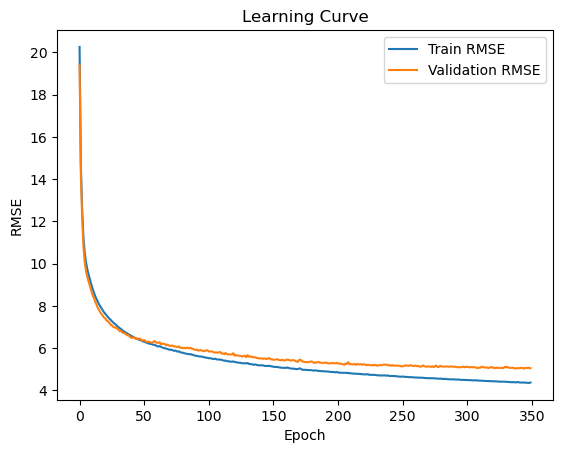

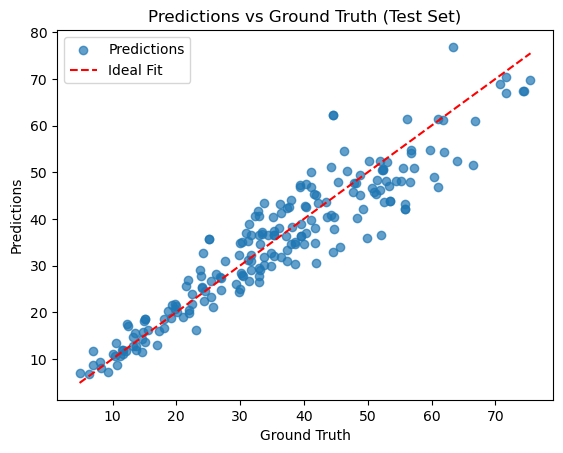

In [281]:
# TODO 10
X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data()

nn = NeuralNetwork(
    hidden_neurons = 50,
    output_neurons = 1,
    batch_size = 32,
    alpha = 0.002,
    epochs = 350,
    seed = 42
)

nn.fit(X_trn, y_trn, X_vld=X_vld, y_vld=y_vld)

y_hat_tst = nn.predict(X_tst)
test_rmse = np.sqrt(mse(y_tst, y_hat_tst))

print(f"Test RMSE: {test_rmse:.4f}")

y_hat_trn = nn.predict(X_trn)

trn_mse_score = mse(y_trn, y_hat_trn)

print(f"Train MSE: {trn_mse_score:.4f}")

y_hat_vld = nn.predict(X_vld)
vld_mse_score = mse(y_vld, y_hat_vld)

print(f"Validation MSE: {vld_mse_score:.4f}")

# Plot the learning curve
plt.plot(nn.trn_error, label='Train RMSE')
plt.plot(nn.vld_error, label='Validation RMSE')
plt.title("Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.show()

# Visualize predictions vs ground truth on the test set
plt.scatter(y_tst, y_hat_tst, alpha=0.7, label='Predictions')
plt.plot([y_tst.min(), y_tst.max()], [y_tst.min(), y_tst.max()], '--', color='red', label='Ideal Fit')
plt.xlabel("Ground Truth")
plt.ylabel("Predictions")
plt.title("Predictions vs Ground Truth (Test Set)")
plt.legend()
plt.show()


In [283]:
X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data()
todo_check([
    ("'nn' in globals()", "The object instance `nn` does not appear to be defined. Make sure your object instance for `NeuralNetwork` is called `nn`."),
    ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
    ("rmse(y_tst, nn.predict(X_tst)) <= 6", "RMSE was not less than or equal to 6"),
],success_msg="+5 points")

Your code PASSED all the code checks! +5 points


In [285]:
X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data()
todo_check([
    ("'nn' in globals()", "The object instance `nn` does not appear to be defined. Make sure your object instance for `NeuralNetwork` is called `nn`."),
    ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
    ("rmse(y_tst, nn.predict(X_tst)) <= 5.7", "RMSE was not less than or equal to 5.7"),
],success_msg="+5 points")

Your code PASSED all the code checks! +5 points


In [287]:
X_trn, y_trn, X_vld, y_vld, X_tst, y_tst = get_preprocessed_data()
todo_check([
    ("'nn' in globals()", "The object instance `nn` does not appear to be defined. Make sure your object instance for `NeuralNetwork` is called `nn`."),
    ("rmse == sklearn.metrics.root_mean_squared_error", "rmse does not seem to be sklearn.metrics.root_mean_squared_error"),
    ("rmse(y_tst, nn.predict(X_tst)) <= 5.5", "RMSE was not less than or equal to 5.5"),
],success_msg="+5 points")

TodoCheckFailed: You passed 2/3 and FAILED the following code checks:

Check [3]: Failed
	Tip: RMSE was not less than or equal to 5.5


## Extra Credit TODO (+1 Point)

Using TensorFlow, create a multi-layer neural network (at least 2 hidden layers) and then train/evaluate the neural network using the concrete dataset. To earn the extra credit point, complete ALL the following requirements.

- Data Loading
    - Load the training, validation, and test datasets.
- Network Creation
    - Create a multi-layer neural network using TensorFlow API
    - Discuss in 2-3 sentences the neural network structure, mentioning  how many layers, number of units per layer, and the activation type per layer.
- Training
    - Train the neural network using Keras `fit()` method or your own code.
    - Provide a learning curve plot to visualize both the training and validation loss during training.
- Validation
    - Compute and display the RMSE for the validation data.
- Testing
    - Compute and display the RMSE for the testing data.

**Hint**
- Keras provides a `validation_data` argument for the `fit()` method to track validation loss and other metrics during training. 